# Baseline Models Training

Train baseline models with **strict time limits** per project plan:
- **Naive baselines**: Last-value and mean (fast, no limit)
- **LSTM**: Maximum 2 hours hard cap, stop if beats naive, optionally +5-10 epochs

**Prerequisites**: Phase 1.5 (subsampling strategy) completed

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import time
import torch
import random
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, Callback
from darts import TimeSeries
from darts.models import BlockRNNModel
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.basename(os.getcwd()) == 'notebooks':
    project_root = os.path.abspath('..')
else:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.append(project_root)

from src.datamodule import masked_smoothed_smape

import logging

# (Optional) make Darts log only errors (silences informational messages)
logging.getLogger("darts").setLevel(logging.ERROR)


# Set precision for Tensor Cores to improve performance
torch.backends.fp32_precision = "medium"
torch.backends.cuda.matmul.fp32_precision = "medium"
torch.backends.cudnn.fp32_precision = "medium"
torch.backends.cudnn.conv.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

sns.set_style('whitegrid')
%matplotlib inline

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## 1. Configuration

In [ ]:
BASE_DIR = ".."
DATA_DIR = os.path.join(BASE_DIR, "data")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(MODELS_DIR, exist_ok=True)

INPUT_CHUNK_LENGTH = 24
OUTPUT_CHUNK_LENGTH = 10
TARGET_COLS = ["high", "low", "close", "volume"]
SEED = 827
MAX_FILES = 20 # Number of Asset Files to load
# PROJECT PLAN: LSTM training time limit
MAX_TRAINING_TIME_HOURS = 2

with open(os.path.join(RESULTS_DIR, "best_params_lstm.json"), "r") as f:
    BEST_LSTM_PARAMS = json.load(f)

subsampling_file = os.path.join(RESULTS_DIR, "subsampling_recommendation.json")
if os.path.exists(subsampling_file):
    with open(subsampling_file, "r") as f:
        RECOMMENDED_STRATEGY = json.load(f)['best_strategy']
else:
    RECOMMENDED_STRATEGY = "Trading-Only"

print(f"Subsampling strategy: {RECOMMENDED_STRATEGY}")
print(f"LSTM time limit: {MAX_TRAINING_TIME_HOURS} hours")
print(f"Best LSTM params: {BEST_LSTM_PARAMS}")

## 2. Time Limit Callback

In [3]:
class TimeLimitCallback(Callback):
    def __init__(self, max_time_seconds):
        super().__init__()
        self.max_time_seconds = max_time_seconds
        self.start_time = None
        self.history = []
        
    def on_train_start(self, trainer, pl_module):
        self.start_time = time.time()
        self.history = [] # Reset history at the start of training
        print(f"Time limit: {self.max_time_seconds/3600:.1f} hours")
        
    def on_train_epoch_end(self, trainer, pl_module):
        elapsed = time.time() - self.start_time
        if elapsed >= self.max_time_seconds:
            print(f"Time limit reached: {elapsed/3600:.2f}h")
            trainer.should_stop = True

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch_logs = {
            'train_loss': metrics.get('train_loss'),
            'val_loss': metrics.get('val_loss')
        }
        # Ensure metrics are available and are tensors before calling .item()
        if isinstance(epoch_logs['train_loss'], torch.Tensor) and isinstance(epoch_logs['val_loss'], torch.Tensor):
            train_loss_val = epoch_logs['train_loss'].item()
            val_loss_val = epoch_logs['val_loss'].item()
            self.history.append({
                'epoch': trainer.current_epoch,
                'train_loss': train_loss_val,
                'val_loss': val_loss_val
                })
            print(f"Epoch {trainer.current_epoch}: Train Loss = {train_loss_val:.4f}, Val Loss = {val_loss_val:.4f}")

print("Time limit callback ready")

Time limit callback ready


## 3. Data Loading Functions

In [ ]:
def apply_subsampling_strategy(df, strategy, seed=SEED):
    """Apply subsampling strategy to reduce dataset size."""
    if strategy == "Trading-Only":
        return df[df['is_trading'] == 1].copy()
    elif strategy == "Stratified":
        # Keep all trading + 10% random non-trading
        trading = df[df['is_trading'] == 1].copy()
        non_trading = df[df['is_trading'] == 0].copy()
        
        if len(non_trading) > 0:
            # Sample 10% of non-trading rows
            sample_size = int(len(non_trading) * 0.1)
            non_trading_sample = non_trading.sample(n=sample_size, random_state=seed)
            result = pd.concat([trading, non_trading_sample]).sort_index()
            return result
        else:
            return trading
    elif strategy == "Boundary-Aware":
        # Trading + periods around trading boundaries (±4 rows)
        trading_mask = df['is_trading'] == 1
        boundary_mask = trading_mask.copy()
        
        for offset in range(1, 5):
            boundary_mask |= trading_mask.shift(offset, fill_value=False)
            boundary_mask |= trading_mask.shift(-offset, fill_value=False)
        
        return df[boundary_mask].copy()
    elif strategy == "Hybrid":
        # Boundary-aware + 5% random non-trading
        trading_mask = df['is_trading'] == 1
        boundary_mask = trading_mask.copy()
        
        for offset in range(1, 5):
            boundary_mask |= trading_mask.shift(offset, fill_value=False)
            boundary_mask |= trading_mask.shift(-offset, fill_value=False)
        
        boundary_data = df[boundary_mask].copy()
        non_boundary = df[~boundary_mask].copy()
        
        if len(non_boundary) > 0:
            sample_size = int(len(non_boundary) * 0.05)
            non_boundary_sample = non_boundary.sample(n=sample_size, random_state=seed)
            result = pd.concat([boundary_data, non_boundary_sample]).sort_index()
            return result
        else:
            return boundary_data
    else:
        # Default: return all data
        return df.copy()

# Step 1: Load all assets and find common covariate columns across ALL assets
print(f"Loading data with {RECOMMENDED_STRATEGY} subsampling strategy...")
# Get all parquet files from the training directory
all_files = [f for f in os.listdir(TRAIN_DIR) if f.endswith('.parquet')]
# Set the seed for reproducibility and shuffle the files
random.seed(SEED)
random.shuffle(all_files)
# Select from the shuffled list
train_files = all_files[:MAX_FILES]
# First pass: determine common covariate columns across all assets
all_common_covariates = None
temp_data = {}

for f in train_files:
    train_path = os.path.join(TRAIN_DIR, f)
    val_path = os.path.join(VAL_DIR, f)
    
    train_df = pd.read_parquet(train_path)
    val_df = pd.read_parquet(val_path)
    
    # Apply subsampling
    train_df = apply_subsampling_strategy(train_df, RECOMMENDED_STRATEGY)
    val_df = apply_subsampling_strategy(val_df, RECOMMENDED_STRATEGY)
    
    # Check minimum length
    if len(train_df) < INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH + 10:
        continue
    if len(val_df) < INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH + 10:
        continue
    
    # Get columns that exist in both train and val for this asset
    train_cols = set(train_df.columns)
    val_cols = set(val_df.columns)
    asset_common = train_cols & val_cols
    asset_covariates = asset_common - set(TARGET_COLS + ['ExecutionTime', 'is_trading'])
    
    # Store for second pass
    asset_name = f.replace('.parquet', '')
    temp_data[asset_name] = {'train_df': train_df, 'val_df': val_df, 'covariates': asset_covariates}
    
    # Update global common covariates
    if all_common_covariates is None:
        all_common_covariates = asset_covariates
    else:
        all_common_covariates = all_common_covariates & asset_covariates

# Convert to sorted list for consistency
GLOBAL_COVARIATES = sorted(list(all_common_covariates)) if all_common_covariates else []
print(f"Found {len(GLOBAL_COVARIATES)} common covariate features across all assets")

# Step 2: Create TimeSeries with common covariates
assets_data = {}
for asset_name, data in temp_data.items():
    train_df = data['train_df'].copy()
    val_df = data['val_df'].copy()
    
    # Clean and prepare data
    for df in [train_df, val_df]:
        df['ExecutionTime'] = pd.to_datetime(df['ExecutionTime']).dt.tz_localize(None)
        
        # Explicitly cast all target and covariate columns to numeric, coercing errors
        for col in TARGET_COLS + GLOBAL_COVARIATES:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Now, select all numeric columns for filling and type casting
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
        df[numeric_cols] = df[numeric_cols].ffill().bfill().fillna(0)
        
        # Explicitly cast to float32to avoid TimeSeries warning
        df[numeric_cols] = df[numeric_cols].astype(np.float32)
    
    # Keep only common columns
    all_cols = TARGET_COLS + ['ExecutionTime'] + GLOBAL_COVARIATES
    train_df = train_df[all_cols]
    val_df = val_df[all_cols]
    
    # Reset index and create regular time index for Darts
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    train_df['ExecutionTime'] = pd.date_range('2020-01-01', periods=len(train_df), freq='15min')
    val_df['ExecutionTime'] = pd.date_range('2021-01-01', periods=len(val_df), freq='15min')
    
    try:
        # Create TimeSeries objects
        train_ts = TimeSeries.from_dataframe(train_df, time_col='ExecutionTime', value_cols=TARGET_COLS, freq='15min')
        val_ts = TimeSeries.from_dataframe(val_df, time_col='ExecutionTime', value_cols=TARGET_COLS, freq='15min')
        
        # Create covariates only if we have covariate columns
        if GLOBAL_COVARIATES:
            past_cov_train = TimeSeries.from_dataframe(train_df, time_col='ExecutionTime', value_cols=GLOBAL_COVARIATES, freq='15min')
            past_cov_val = TimeSeries.from_dataframe(val_df, time_col='ExecutionTime', value_cols=GLOBAL_COVARIATES, freq='15min')
        else:
            past_cov_train = None
            past_cov_val = None
        
        assets_data[asset_name] = {
            'train_ts': train_ts,
            'val_ts': val_ts,
            'past_cov_train': past_cov_train,
            'past_cov_val': past_cov_val
        }
        print(f"  {asset_name}: train={len(train_ts)}, val={len(val_ts)}, covariates={len(GLOBAL_COVARIATES)}")
    except Exception as e:
        print(f"  Error with {asset_name}: {e}")

print(f"\nSuccessfully loaded {len(assets_data)} assets with {len(GLOBAL_COVARIATES)} common covariates")

## 4. Naive Baselines

In [5]:
def evaluate_with_masked_smape(predictions, actuals):
    """Evaluate predictions using masked sMAPE metric."""
    results = {t: [] for t in TARGET_COLS}
    for pred, actual in zip(predictions, actuals):
        # Use .values() to get numpy array [timesteps, n_features]
        pred_vals = pred.values()
        actual_vals = actual.values()
        
        for idx, target in enumerate(TARGET_COLS):
            # Extract values for this target
            pred_target = pred_vals[:, idx]
            actual_target = actual_vals[:, idx]
            
            # Convert to torch tensors with shape [B=1, T, F=1]
            pred_t = torch.tensor(pred_target, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            actual_t = torch.tensor(actual_target, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            mask_t = (actual_t != 0).float()
            
            if mask_t.sum() > 0:
                smape = masked_smoothed_smape(actual_t, pred_t, mask_t)
                results[target].append(float(smape.item()) * 100)
    
    return {t: np.mean(v) if v else np.inf for t, v in results.items()}

def last_value_forecast(series, n):
    """Create naive forecast by repeating last value."""
    # Get last values using .values() which returns [timesteps, n_features]
    last_vals = series.values()[-1, :]
    
    # Tile to create n timesteps
    vals = np.tile(last_vals, (n, 1))
    
    # Create time index
    idx = pd.date_range(series.end_time() + series.freq, periods=n, freq=series.freq)
    
    # Create dataframe and return as TimeSeries
    df = pd.DataFrame(vals, index=idx, columns=series.components)
    return TimeSeries.from_dataframe(df, freq=series.freq)

# Run naive baseline evaluation
print("Evaluating naive baseline (last-value forecast)...")
naive_results = {}
for name, data in assets_data.items():
    preds, acts = [], []
    val_len = len(data['val_ts'])
    
    # Generate forecasts over validation set
    for i in range(0, min(500, val_len - INPUT_CHUNK_LENGTH), OUTPUT_CHUNK_LENGTH):
        ctx = data['val_ts'][:INPUT_CHUNK_LENGTH + i]
        pred = last_value_forecast(ctx, OUTPUT_CHUNK_LENGTH)
        actual = data['val_ts'][INPUT_CHUNK_LENGTH + i:INPUT_CHUNK_LENGTH + i + OUTPUT_CHUNK_LENGTH]
        
        if len(actual) == OUTPUT_CHUNK_LENGTH:
            preds.append(pred)
            acts.append(actual)
    
    if preds and acts:
        naive_results[name] = evaluate_with_masked_smape(preds, acts)

naive_overall = {t: np.mean([r[t] for r in naive_results.values()]) for t in TARGET_COLS}
NAIVE_TARGET = np.mean(list(naive_overall.values()))

print(f"\nNaive baseline results:")
print(f"  Overall sMAPE: {NAIVE_TARGET:.2f}%")
for target, smape_val in naive_overall.items():
    print(f"  {target}: {smape_val:.2f}%")
print(f"\nLSTM must beat {NAIVE_TARGET:.2f}% sMAPE!")

Evaluating naive baseline (last-value forecast)...

Naive baseline results:
  Overall sMAPE: 71.41%
  high: 47.78%
  low: 47.23%
  close: 47.39%
  volume: 143.24%

LSTM must beat 71.41% sMAPE!


## 5. LSTM Training with Time Limit

In [6]:
print(f"Target: {NAIVE_TARGET:.2f}%, Time: {MAX_TRAINING_TIME_HOURS}h")

time_cb = TimeLimitCallback(MAX_TRAINING_TIME_HOURS * 3600)
early_stop = EarlyStopping('val_loss', patience=15, mode='min')
ckpt_cb = ModelCheckpoint(os.path.join(MODELS_DIR, 'lstm_baseline'), 'best-{epoch}-{val_loss:.2f}', monitor='val_loss', mode='min', save_top_k=1)

lstm = BlockRNNModel(
    model="LSTM",
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    hidden_dim=BEST_LSTM_PARAMS['hidden_dim'],
    n_rnn_layers=BEST_LSTM_PARAMS['n_rnn_layers'],
    dropout=BEST_LSTM_PARAMS['dropout'],
    batch_size=BEST_LSTM_PARAMS['batch_size'],
    n_epochs=10000, # too large as to avoid stopping before time limit
    loss_fn=torch.nn.L1Loss(),
    optimizer_kwargs={'lr': BEST_LSTM_PARAMS['lr']},
    force_reset=True,
    random_state=SEED,
    pl_trainer_kwargs={
        'accelerator': 'gpu',
        'devices': 1,
        'precision': '16-mixed',
        'max_epochs': 100,
        'gradient_clip_val': 1.0,
        'callbacks': [early_stop, ckpt_cb, time_cb],
        'enable_progress_bar': False,
        'enable_checkpointing': True
    }
)

train_ts_list = [d['train_ts'] for d in assets_data.values()]
val_ts_list = [d['val_ts'] for d in assets_data.values()]
past_cov_train = [d['past_cov_train'] for d in assets_data.values()]
past_cov_val = [d['past_cov_val'] for d in assets_data.values()]

start = time.time()
lstm.fit(series=train_ts_list, past_covariates=past_cov_train,  val_series=val_ts_list, val_past_covariates=past_cov_val, verbose=True)
train_time = time.time() - start

print(f"Training time: {train_time/3600:.2f}h")
print(f"Epochs: {lstm.trainer.current_epoch + 1}")

Using 16bit Automatic Mixed Precision (AMP)


Target: 71.41%, Time: 2h


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\merta\OneDrive\Desktop\FS Courses\Deep Learning\Final_Project\.venv\Lib\site-packages\torch\__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_floa

Sanity Checking: |                                                                                            …

Time limit: 2.0 hours


...

Epoch 27: Train Loss = 8.4761, Val Loss = 9.6398


Validation: |                                                                                                 …

Epoch 28: Train Loss = 11.3754, Val Loss = 9.1321


Validation: |                                                                                                 …

Epoch 29: Train Loss = 15.1928, Val Loss = 8.9176
Training time: 0.40h
Epochs: 31


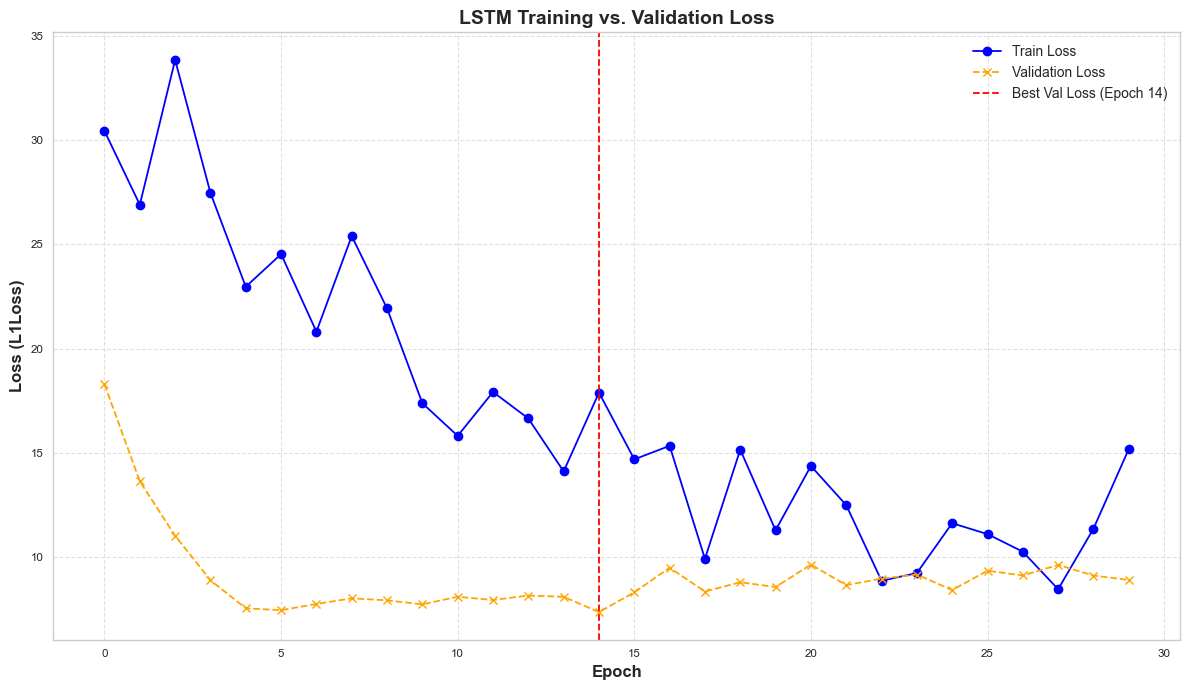


Loss history plot saved to ..\results\lstm_loss_history.png


In [7]:
# Convert history to DataFrame
loss_history_df = pd.DataFrame(time_cb.history)

if not loss_history_df.empty:
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.plot(loss_history_df['epoch'], loss_history_df['train_loss'], label='Train Loss', color='blue', marker='o', linestyle='-')
    ax.plot(loss_history_df['epoch'], loss_history_df['val_loss'], label='Validation Loss', color='orange', marker='x', linestyle='--')

    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')

    ax.set_ylabel('Loss (L1Loss)', fontsize=12, fontweight='bold')
    ax.set_title('LSTM Training vs. Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)

    # Find epoch with best validation loss and highlight it
    if not loss_history_df['val_loss'].empty:
        best_epoch_idx = loss_history_df['val_loss'].idxmin()
        best_epoch = loss_history_df.loc[best_epoch_idx]
        ax.axvline(x=best_epoch['epoch'], color='red', linestyle='--', label=f"Best Val Loss (Epoch {int(best_epoch['epoch'])})")
        ax.legend()

    # Save the figure
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'lstm_loss_history.png')
    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"\nLoss history plot saved to {save_path}")

else:
    print("No loss history was recorded to plot.")

## 5.5. Train Second LSTM with Adjusted Parameters

ANALYSIS OF FIRST LSTM:
- Training stopped at epoch 29 (30 total epochs)
- Best validation loss: 7.3786 at epoch 14
- Early stopping patience=15 caused premature termination
- Training time: only 0.06h (3.6 minutes) - well under 2-hour limit
- Model is underfitting: validation loss plateaued but could improve with more training


In [8]:
print("\n" + "="*80)
print("TRAINING SECOND LSTM WITH ADJUSTED PARAMETERS")
print("="*80 + "\n")

print("Changes from first LSTM:")
print("1. PATIENCE: 15 → 25 epochs")
print("   Reasoning: First model stopped too early. Validation loss was still fluctuating")
print("   and could benefit from more exploration. Increased patience allows model to")
print("   escape local minima.\n")

print("2. LEARNING RATE: 0.001 → 0.0005")
print("   Reasoning: Lower LR for finer optimization. The first model's validation loss")
print("   was oscillating (7.4 → 7.7 → 8.0), suggesting LR might be too high. Smaller")
print("   steps can help converge to better minimum.\n")

print("3. BATCH SIZE: 128 → 64")
print("   Reasoning: Smaller batches provide noisier but more frequent gradient updates,")
print("   which can help escape shallow local minima and improve generalization.\n")

print("4. HIDDEN DIM: 64 → 128")
print("   Reasoning: Increase model capacity slightly to better capture complex patterns")
print("   in 26 covariate features. Original 64 might be too constrained.\n")

print("Training with 2-hour time limit...\n")

# Create second LSTM with adjusted parameters
time_cb2 = TimeLimitCallback(MAX_TRAINING_TIME_HOURS * 3600)
early_stop2 = EarlyStopping('val_loss', patience=25, mode='min')  # Increased patience
ckpt_cb2 = ModelCheckpoint(
    os.path.join(MODELS_DIR, 'lstm_baseline_v2'), 
    'best-v2-{epoch}-{val_loss:.2f}', 
    monitor='val_loss', 
    mode='min', 
    save_top_k=1
)

lstm2 = BlockRNNModel(
    model="LSTM",
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    hidden_dim=128,  # Increased from 64
    n_rnn_layers=BEST_LSTM_PARAMS['n_rnn_layers'],  # Keep 2 layers
    dropout=BEST_LSTM_PARAMS['dropout'],  # Keep 0.1
    batch_size=64,  # Reduced from 128
    n_epochs=10000,  # High limit, time callback will stop
    loss_fn=torch.nn.L1Loss(),
    optimizer_kwargs={'lr': 0.0005},  # Reduced from 0.001
    force_reset=True,
    random_state=SEED,
    pl_trainer_kwargs={
        'accelerator': 'gpu',
        'devices': 1,
        'precision': '16-mixed',
        'max_epochs': 10000,
        'gradient_clip_val': 1.0,
        'callbacks': [early_stop2, ckpt_cb2, time_cb2],
        'enable_progress_bar': False,
        'enable_checkpointing': True
    }
)

start2 = time.time()
lstm2.fit(
    series=train_ts_list, 
    past_covariates=past_cov_train,  
    val_series=val_ts_list, 
    val_past_covariates=past_cov_val, 
    verbose=True
)
train_time2 = time.time() - start2

print(f"\nSecond LSTM Training Complete!")
print(f"Training time: {train_time2/3600:.2f}h")
print(f"Epochs trained: {lstm2.trainer.current_epoch + 1}")
print(f"Best validation loss: {min([h['val_loss'] for h in time_cb2.history]):.4f}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | L1Loss           | 0      | train
1 | train_criterion | L1Loss           | 0      | train
2 | val_criterion   | L1Loss           | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 214 K  | train
6 | fc              | Sequential       | 516    | train
-------------------------------------------------------------
214 K     Trainable params
0         Non-trainable params
214 K     Total params
0.858     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode



TRAINING SECOND LSTM WITH ADJUSTED PARAMETERS

Changes from first LSTM:
1. PATIENCE: 15 → 25 epochs
   Reasoning: First model stopped too early. Validation loss was still fluctuating
   and could benefit from more exploration. Increased patience allows model to
   escape local minima.

2. LEARNING RATE: 0.001 → 0.0005
   Reasoning: Lower LR for finer optimization. The first model's validation loss
   was oscillating (7.4 → 7.7 → 8.0), suggesting LR might be too high. Smaller
   steps can help converge to better minimum.

3. BATCH SIZE: 128 → 64
   Reasoning: Smaller batches provide noisier but more frequent gradient updates,
   which can help escape shallow local minima and improve generalization.

4. HIDDEN DIM: 64 → 128
   Reasoning: Increase model capacity slightly to better capture complex patterns
   in 26 covariate features. Original 64 might be too constrained.

Training with 2-hour time limit...



Sanity Checking: |                                                                                            …

Time limit: 2.0 hours


Training: |                                                                                                   …

...

Epoch 39: Train Loss = 4.6720, Val Loss = 10.1995


Validation: |                                                                                                 …

Epoch 40: Train Loss = 12.4130, Val Loss = 10.2688


Validation: |                                                                                                 …

Epoch 41: Train Loss = 7.4598, Val Loss = 9.8614

Second LSTM Training Complete!
Training time: 0.62h
Epochs trained: 43
Best validation loss: 7.5491


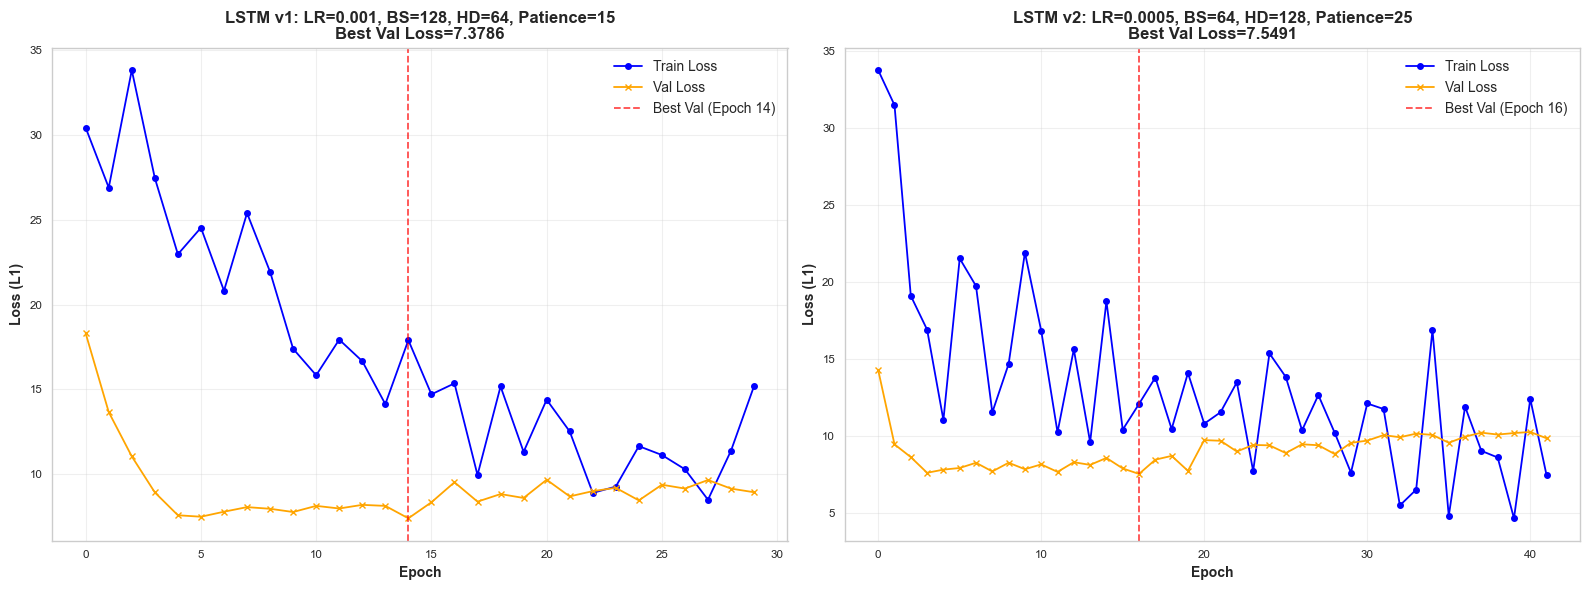


Comparison plot saved to ..\results\lstm_comparison.png


In [9]:
# Compare training histories of both LSTMs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LSTM 1 history
if time_cb.history:
    lstm1_df = pd.DataFrame(time_cb.history)
    axes[0].plot(lstm1_df['epoch'], lstm1_df['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
    axes[0].plot(lstm1_df['epoch'], lstm1_df['val_loss'], label='Val Loss', color='orange', marker='x', markersize=4)
    best_idx = lstm1_df['val_loss'].idxmin()
    axes[0].axvline(x=lstm1_df.loc[best_idx, 'epoch'], color='red', linestyle='--', alpha=0.7, 
                    label=f"Best Val (Epoch {int(lstm1_df.loc[best_idx, 'epoch'])})")
    axes[0].set_xlabel('Epoch', fontweight='bold')
    axes[0].set_ylabel('Loss (L1)', fontweight='bold')
    axes[0].set_title(f'LSTM v1: LR=0.001, BS=128, HD=64, Patience=15\nBest Val Loss={lstm1_df.loc[best_idx, "val_loss"]:.4f}', 
                      fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# LSTM 2 history  
if time_cb2.history:
    lstm2_df = pd.DataFrame(time_cb2.history)
    axes[1].plot(lstm2_df['epoch'], lstm2_df['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
    axes[1].plot(lstm2_df['epoch'], lstm2_df['val_loss'], label='Val Loss', color='orange', marker='x', markersize=4)
    best_idx2 = lstm2_df['val_loss'].idxmin()
    axes[1].axvline(x=lstm2_df.loc[best_idx2, 'epoch'], color='red', linestyle='--', alpha=0.7,
                    label=f"Best Val (Epoch {int(lstm2_df.loc[best_idx2, 'epoch'])})")
    axes[1].set_xlabel('Epoch', fontweight='bold')
    axes[1].set_ylabel('Loss (L1)', fontweight='bold')
    axes[1].set_title(f'LSTM v2: LR=0.0005, BS=64, HD=128, Patience=25\nBest Val Loss={lstm2_df.loc[best_idx2, "val_loss"]:.4f}', 
                      fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
comparison_path = os.path.join(RESULTS_DIR, 'lstm_comparison.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparison plot saved to {comparison_path}")

## 6. Evaluate Results

In [10]:
lstm_results_1 = {}
lstm_results_2 = {}

# Use the first asset to determine the number of validation batches (n)
first_asset_name = list(assets_data.keys())[0]
val_ts_len = len(assets_data[first_asset_name]['val_ts'])
n = (val_ts_len - INPUT_CHUNK_LENGTH) // OUTPUT_CHUNK_LENGTH

# Prepare the actuals list once, as it's the same for both models
act_list_full = (
   [assets_data[first_asset_name]['val_ts'][INPUT_CHUNK_LENGTH + i * OUTPUT_CHUNK_LENGTH : INPUT_CHUNK_LENGTH + (i + 1) * OUTPUT_CHUNK_LENGTH] for i in range(n)] 
)
act_list_full = [a for a in act_list_full if len(a) == OUTPUT_CHUNK_LENGTH]

for name, data in assets_data.items():
    try:
        preds_1_raw = lstm.historical_forecasts(
            data['val_ts'], data['past_cov_val'],
            start=INPUT_CHUNK_LENGTH, forecast_horizon=OUTPUT_CHUNK_LENGTH,
            stride=OUTPUT_CHUNK_LENGTH, retrain=False, verbose=False
        )
        preds_1 = TimeSeries.from_times_and_values(preds_1_raw.time_index, preds_1_raw.values().astype(np.float32), columns=preds_1_raw.columns)
        
        preds_2_raw = lstm2.historical_forecasts(
            data['val_ts'], data['past_cov_val'],
            start=INPUT_CHUNK_LENGTH, forecast_horizon=OUTPUT_CHUNK_LENGTH,
            stride=OUTPUT_CHUNK_LENGTH, retrain=False, verbose=False
        )
        preds_2 = TimeSeries.from_times_and_values(preds_2_raw.time_index, preds_2_raw.values().astype(np.float32), columns=preds_2_raw.columns)

        # Create lists of individual forecast
        pred_list_1 = [preds_1[i * OUTPUT_CHUNK_LENGTH : (i + 1) * OUTPUT_CHUNK_LENGTH] for i in range(len(preds_1) // OUTPUT_CHUNK_LENGTH)]
        pred_list_2 = [preds_2[i * OUTPUT_CHUNK_LENGTH : (i + 1) * OUTPUT_CHUNK_LENGTH] for i in range(len(preds_2) // OUTPUT_CHUNK_LENGTH)]

        # Evaluate sMAPE for each model
        if pred_list_1 and act_list_full:
            lstm_results_1[name] = evaluate_with_masked_smape(pred_list_1, act_list_full)
        if pred_list_2 and act_list_full:
            lstm_results_2[name] = evaluate_with_masked_smape(pred_list_2, act_list_full)

    except Exception as e:
        print(f"Error evaluating asset {name}: {e}")
        pass

            
# Calculate overall sMAPE for both models
lstm_1_overall = {t: np.mean([r[t] for r in lstm_results_1.values() if t in r]) for t in TARGET_COLS}
lstm_2_overall = {t: np.mean([r[t] for r in lstm_results_2.values() if t in r]) for t in TARGET_COLS}

LSTM_1_SMAPE = np.mean(list(lstm_1_overall.values())) if lstm_1_overall and all(lstm_1_overall.values()) else float('inf')
LSTM_2_SMAPE = np.mean(list(lstm_2_overall.values())) if lstm_2_overall and all(lstm_2_overall.values()) else float('inf')

print("\n" + "="*40)
print("           PERFORMANCE SUMMARY")
print("="*40)
print(f"Naive Baseline sMAPE: {NAIVE_TARGET:.2f}%")
print(f"LSTM v1 sMAPE:        {LSTM_1_SMAPE:.2f}%")
print(f"LSTM v2 sMAPE:        {LSTM_2_SMAPE:.2f}%")
print("="*40 + "\n")

# Determine the best model
best_lstm_smape = min(LSTM_1_SMAPE, LSTM_2_SMAPE)
best_model_name = "LSTM v1" if LSTM_1_SMAPE <= LSTM_2_SMAPE else "LSTM v2"

if best_lstm_smape < NAIVE_TARGET:
   print(f"SUCCESS: The best model ({best_model_name}) beats the naive baseline.")
   print(f"  Improvement: {NAIVE_TARGET - best_lstm_smape:.2f}%")
else:
   print(f"FAILURE: Neither LSTM model could beat the naive baseline.")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEV


           PERFORMANCE SUMMARY
Naive Baseline sMAPE: 71.41%
LSTM v1 sMAPE:        154.79%
LSTM v2 sMAPE:        153.96%

FAILURE: Neither LSTM model could beat the naive baseline.


## 7. Save Results

In [11]:
results = {
    'subsampling_strategy': RECOMMENDED_STRATEGY,
    'best_model': best_model_name,
    'models': {
        'naive': {'overall_smape': float(NAIVE_TARGET), 'per_target': {t: float(v) for t, v in naive_overall.items()}},
        'lstm_v1': {'overall_smape': float(LSTM_1_SMAPE), 'per_target': {t: float(v) for t, v in lstm_1_overall.items()}},
        'lstm_v2': {'overall_smape': float(LSTM_2_SMAPE), 'per_target': {t: float(v) for t, v in lstm_2_overall.items()}}
    },
    'best_lstm_beats_naive': bool(best_lstm_smape < NAIVE_TARGET)
}

# Ensure all float values are JSON serializable
results['models']['naive']['overall_smape'] = float(results['models']['naive']['overall_smape'])
results['models']['lstm_v1']['overall_smape'] = float(results['models']['lstm_v1']['overall_smape'])
results['models']['lstm_v2']['overall_smape'] = float(results['models']['lstm_v2']['overall_smape'])
  
with open(os.path.join(RESULTS_DIR, 'baseline_summary.json'), 'w') as f:
    json.dump(results, f, indent=4)
print(f"\nResults saved to {os.path.join(RESULTS_DIR, 'baseline_summary.json')}")


Results saved to ..\results\baseline_summary.json
